In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import xarray as xr
from scipy.stats import zscore
from scipy.special import logit, expit
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
from matplotlib.colors import LinearSegmentedColormap
import scipy.cluster.hierarchy as hc
import scipy.spatial as sp
from ALLCools.mcds import MCDS

In [5]:
mcds_paths = [
    "/ceph/MethDev/pbio/andy/JW/section_4/All_mcds_dmw3_0.mcds",
    "/ceph/MethDev/pbio/andy/JW/section_4/All_mcds_dmw3_1.mcds",
]

# Adjust if your hazel files are actually elsewhere — find them with:
#   find /ceph/MethDev/pbio/andy/JW -name "count_Arab13_with_TEs.csv"
rna_path  = "/ceph/MethDev/pbio/hazel/count_Arab13_with_TEs.csv"
meta_path = "/ceph/MethDev/pbio/hazel/merged_cluster_assignments.csv"
genes_bed = "/ceph/MethDev/pbio/andy/JW/section_4/genes.fixed.bed"

fig_outdir = "/ceph/MethDev/pbio/andy/JW/section_4/kay/figures/heatmaps"

MC_TYPE = "CGN"
MIN_COV = 50
TOP_N = 300

mcds = MCDS.open(mcds_paths=mcds_paths, var_dim="dmw")
rna  = pd.read_csv(rna_path).T
meta = pd.read_csv(meta_path).set_index("cell_id")

print(f"MCDS dims: {dict(mcds.dims)}")
print(f"RNA: {rna.shape}, Meta: {meta.shape}")

MCDS dims: {'cell': 6071, 'count_type': 2, 'dmw': 22467, 'mc_type': 4}
RNA: (6071, 64507), Meta: (5908, 1)


In [6]:
import pandas as pd

# === Load curated chunks from GFF ===
# Try tab-separated first (standard GFF), fall back to whitespace if needed
try:
    new_dmws = pd.read_csv(
        "/ceph/MethDev/pbio/andy/JW/section_4/chunks_CG_minfilt.gff",
        sep="\t", header=None, comment="#",
        usecols=[0, 3, 4],
        names=["chrom", "start", "end"],
    )
except Exception:
    new_dmws = pd.read_csv(
        "/ceph/MethDev/pbio/andy/JW/section_4/chunks_CG_minfilt.gff",
        sep=r"\s+", header=None, comment="#",
        usecols=[0, 3, 4],
        names=["chrom", "start", "end"],
    )

new_dmws["start"] = new_dmws["start"].astype(int)
new_dmws["end"]   = new_dmws["end"].astype(int)

print(f"Curated chunks in GFF: {len(new_dmws)}")
print(f"GFF chrom values:  {sorted(new_dmws['chrom'].unique())}")
print("GFF head:")
print(new_dmws.head())

# === Existing MCDS coordinate table ===
dmw_bed_full = pd.DataFrame({
    "chrom":  mcds["dmw_chrom"].values,
    "start":  mcds["dmw_start"].values.astype(int),
    "end":    mcds["dmw_end"].values.astype(int),
    "dmw_id": mcds.get_index("dmw").values,
})
print(f"\nMCDS chrom values: {sorted(dmw_bed_full['chrom'].astype(str).unique())}")
print("MCDS head:")
print(dmw_bed_full.head())

Curated chunks in GFF: 3124
GFF chrom values:  ['chr1', 'chr2', 'chr3', 'chr4', 'chr5']
GFF head:
  chrom   start     end
0  chr1   76800   77300
1  chr1  281800  282200
2  chr1  282600  282800
3  chr1  292200  292600
4  chr1  296600  296800

MCDS chrom values: ['1', '2', '3', '4', '5']
MCDS head:
   chrom  start    end dmw_id
0      1  23901  25400  dmw=1
1      1  25601  27200  dmw=2
2      1  27401  30200  dmw=3
3      1  30401  30900  dmw=4
4      1  31601  32000  dmw=5


In [7]:
# === Harmonize and match ===
new_dmws_fixed = new_dmws.copy()
new_dmws_fixed["chrom"] = new_dmws_fixed["chrom"].str.replace("^chr", "", regex=True).astype(str)
new_dmws_fixed["start"] = new_dmws_fixed["start"] + 1   # 0-based BED → 1-based MCDS

# Cast MCDS chrom to string too
dmw_bed_full["chrom"] = dmw_bed_full["chrom"].astype(str)

print(f"After fix — GFF chrom values: {sorted(new_dmws_fixed['chrom'].unique())}")
print(f"After fix — MCDS chrom values: {sorted(dmw_bed_full['chrom'].unique())}")
print("After fix — GFF head:")
print(new_dmws_fixed.head())

# Exact-coordinate match
merged = dmw_bed_full.merge(
    new_dmws_fixed, on=["chrom", "start", "end"], how="inner"
)
print(f"\nExact matches: {len(merged)} / {len(new_dmws_fixed)} curated chunks")
print(f"                {len(merged)} / {len(dmw_bed_full)} MCDS DMWs")

After fix — GFF chrom values: ['1', '2', '3', '4', '5']
After fix — MCDS chrom values: ['1', '2', '3', '4', '5']
After fix — GFF head:
  chrom   start     end
0     1   76801   77300
1     1  281801  282200
2     1  282601  282800
3     1  292201  292600
4     1  296601  296800

Exact matches: 3124 / 3124 curated chunks
                3124 / 22467 MCDS DMWs


In [8]:
# === Apply curated-chunk filter to MCDS ===
keep_ids = merged["dmw_id"].tolist()
mcds = mcds.sel(dmw=keep_ids)
print(f"Filtered MCDS dims: {dict(mcds.dims)}")
# Should show {'cell': 6071, 'dmw': 3124, ...}

Filtered MCDS dims: {'cell': 6071, 'count_type': 2, 'dmw': 3124, 'mc_type': 4}


In [9]:
# ---------- Cell 4: RNA per-cluster matrix (almost unchanged) ----------
common_cells = rna.index.intersection(meta.index)
rna_aligned  = rna.loc[common_cells]

cell_totals = rna_aligned.sum(axis=1)
rna_cpm     = rna_aligned.div(cell_totals, axis=0) * 1e6
rna_log1p   = np.log1p(rna_cpm)

rna_log1p["cluster"]  = meta.loc[common_cells, "merged_cluster"]
cluster_rna_matrix    = rna_log1p.groupby("cluster").mean().T   # genes × clusters
print(f"RNA cluster matrix: {cluster_rna_matrix.shape}")

RNA cluster matrix: (64507, 17)


In [10]:
# ---------- Cell 5: DMW methylation residuals per cluster ----------
# KEY CHANGE 2: dmw_da instead of gene_da; check your mc_type label
print("Available mc_types:", mcds.coords["mc_type"].values.tolist())
MC_TYPE = "CGN"   # change if needed

# Pull mc and cov as cell × dmw matrices
mCG_mc  = mcds.sel(mc_type=MC_TYPE, count_type="mc").dmw_da.to_pandas()
mCG_cov = mcds.sel(mc_type=MC_TYPE, count_type="cov").dmw_da.to_pandas()

# Restrict to cells with metadata
mCG_mc  = mCG_mc.loc[mCG_mc.index.intersection(meta.index)]
mCG_cov = mCG_cov.loc[mCG_cov.index.intersection(meta.index)]

mCG_mc["cluster"]  = meta.loc[mCG_mc.index,  "merged_cluster"]
mCG_cov["cluster"] = meta.loc[mCG_cov.index, "merged_cluster"]

cluster_c = mCG_mc.groupby("cluster").sum().T   # dmw × clusters
cluster_m = mCG_cov.groupby("cluster").sum().T

# --- logit-adjusted residuals (same math as original, dmw instead of gene) ---
global_c = cluster_c.sum(axis=0)
global_m = cluster_m.sum(axis=0)
global_p = global_c / global_m
d        = logit(np.clip(global_p, 1e-6, 1 - 1e-6))
deltas   = d - np.average(d, weights=global_m)

dmw_c = cluster_c.sum(axis=1)
dmw_m = cluster_m.sum(axis=1)

# Coverage filter — DMWs are smaller than genes so you may want a lower threshold
valid = dmw_m >= 50
cluster_c, cluster_m = cluster_c[valid], cluster_m[valid]
dmw_c, dmw_m         = dmw_c[valid], dmw_m[valid]

pbar = np.clip(dmw_c / dmw_m, 1e-6, 1 - 1e-6)
expected_logit = logit(pbar).values[:, None] + deltas.values[None, :]
p0_df = pd.DataFrame(expit(expected_logit),
                     index=cluster_c.index, columns=cluster_c.columns)

obs_p = (cluster_c / cluster_m.replace(0, np.nan)).fillna(0)
adj_meth_matrix = obs_p - p0_df

# Keep DMWs with meaningful methylation in at least one cluster
highly_meth = obs_p[obs_p.apply(lambda x: (x >= 0.1).any(), axis=1)].index
filtered_meth_df = adj_meth_matrix.loc[highly_meth]
print(f"Filtered DMW residual matrix: {filtered_meth_df.shape}")

Available mc_types: ['CHH', 'CHG', 'CHN', 'CGN']
Filtered DMW residual matrix: (3054, 17)


In [11]:
# DMW → gene mapping by gene-body overlap
import bioframe as bf

# REBUILD dmw_bed fresh from MCDS so re-running this cell is safe
dmw_bed = pd.DataFrame({
    "chrom":  mcds["dmw_chrom"].values,
    "start":  mcds["dmw_start"].values.astype(int),
    "end":    mcds["dmw_end"].values.astype(int),
    "dmw_id": mcds.get_index("dmw").values,
})

# Load genes
genes = pd.read_csv(
    genes_bed, sep="\t", header=None,
    names=["chrom", "start", "end", "gene", "score", "strand"],
    usecols=[0, 1, 2, 3],
)
print(f"Loaded {len(genes)} gene records")
print(f"Gene chrom values BEFORE: {sorted(genes['chrom'].unique())}")
print(f"DMW chrom values BEFORE:  {sorted(dmw_bed['chrom'].unique())}")

# Harmonize: add lowercase 'chr' prefix to DMW chroms (which are bare integers)
dmw_bed["chrom"] = "chr" + dmw_bed["chrom"].astype(str)

print(f"\nDMW chrom values AFTER:   {sorted(dmw_bed['chrom'].unique())}")

assert set(dmw_bed["chrom"]) & set(genes["chrom"]), \
    "No shared chromosome names — harmonize naming above before continuing."

# Inner overlap
overlaps = bf.overlap(
    dmw_bed, genes,
    cols1=("chrom", "start", "end"),
    cols2=("chrom", "start", "end"),
    how="inner",
    suffixes=("_dmw", "_gene"),
)
print("Overlap columns:", overlaps.columns.tolist())

# Find the dmw_id and gene columns regardless of suffix
dmw_col  = next(c for c in overlaps.columns if c.startswith("dmw_id"))
gene_col = next(c for c in overlaps.columns if c == "gene" or c.startswith("gene_"))

dmw_to_gene = (
    overlaps[[dmw_col, gene_col]]
    .rename(columns={dmw_col: "dmw_id", gene_col: "gene"})
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f"\nDMW–gene overlap pairs: {len(dmw_to_gene)}")
print(f"Unique DMWs with a gene:    {dmw_to_gene['dmw_id'].nunique()}")
print(f"Unique genes hit by a DMW:  {dmw_to_gene['gene'].nunique()}")
multi = dmw_to_gene.groupby("dmw_id").size()
print(f"DMWs overlapping >1 gene:   {(multi > 1).sum()} (max {multi.max()})")

Loaded 33326 gene records
Gene chrom values BEFORE: ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chrC', 'chrM']
DMW chrom values BEFORE:  [1, 2, 3, 4, 5]

DMW chrom values AFTER:   ['chr1', 'chr2', 'chr3', 'chr4', 'chr5']
Overlap columns: ['chrom_dmw', 'start_dmw', 'end_dmw', 'dmw_id_dmw', 'chrom_gene', 'start_gene', 'end_gene', 'gene_gene']

DMW–gene overlap pairs: 1343
Unique DMWs with a gene:    1233
Unique genes hit by a DMW:  1237
DMWs overlapping >1 gene:   107 (max 3)


In [12]:
# ---------- Cell 7: WLS correlation per (DMW, gene) pair ----------
# After mapping, we correlate each DMW's residual profile across clusters
# with its assigned gene's expression profile.
results = []
for _, row in dmw_to_gene.iterrows():
    dmw_id, gene = row["dmw_id"], row["gene"]
    if dmw_id not in filtered_meth_df.index or gene not in cluster_rna_matrix.index:
        continue

    rna_vals  = cluster_rna_matrix.loc[gene].values
    meth_vals = filtered_meth_df.loc[dmw_id].values
    weights   = cluster_m.loc[dmw_id].values

    if np.std(rna_vals) == 0 or np.std(meth_vals) == 0:
        continue

    X = sm.add_constant(zscore(meth_vals))
    try:
        wls = sm.WLS(zscore(rna_vals), X, weights=weights).fit()
        results.append((dmw_id, gene, wls.params[1], wls.pvalues[1]))
    except Exception:
        continue

stats_df = pd.DataFrame(results, columns=["dmw_id", "gene", "rho", "p_value"])
stats_df["fdr"] = multipletests(stats_df["p_value"], method="fdr_bh")[1]
print(stats_df.sort_values("rho").head(20))

         dmw_id       gene       rho       p_value       fdr
660   dmw=16844  AT4G35090 -1.600570  3.482254e-03  0.021417
1077  dmw=11073  AT3G21670 -1.369989  3.443757e-05  0.000740
696    dmw=4806  AT1G68780 -1.280814  1.307790e-04  0.001897
954    dmw=4964  AT1G71140 -1.271450  2.795345e-05  0.000647
304    dmw=5778  AT2G01918 -1.244426  8.443408e-08  0.000010
540   dmw=14094  AT4G04330 -1.236987  6.086608e-04  0.005770
960    dmw=5164  AT1G73750 -1.201590  9.361889e-05  0.001515
776    dmw=1801  AT1G23310 -1.158280  2.429429e-03  0.016250
1170  dmw=12968  AT3G53460 -1.155136  9.385212e-03  0.044840
624   dmw=15745  AT4G21510 -1.154096  4.509969e-04  0.004722
488    dmw=8809  AT2G40960 -1.149572  5.301931e-03  0.029282
47    dmw=18186  AT5G13630 -1.134228  6.441813e-05  0.001157
134   dmw=20244  AT5G38430 -1.133997  1.026811e-06  0.000062
395    dmw=6714  AT2G15050 -1.114484  3.737998e-07  0.000026
1097  dmw=11393  AT3G26290 -1.112727  6.043325e-06  0.000220
844    dmw=2877  AT1G429

Plotting top 300 DMW-gene pairs.


<Figure size 640x480 with 0 Axes>

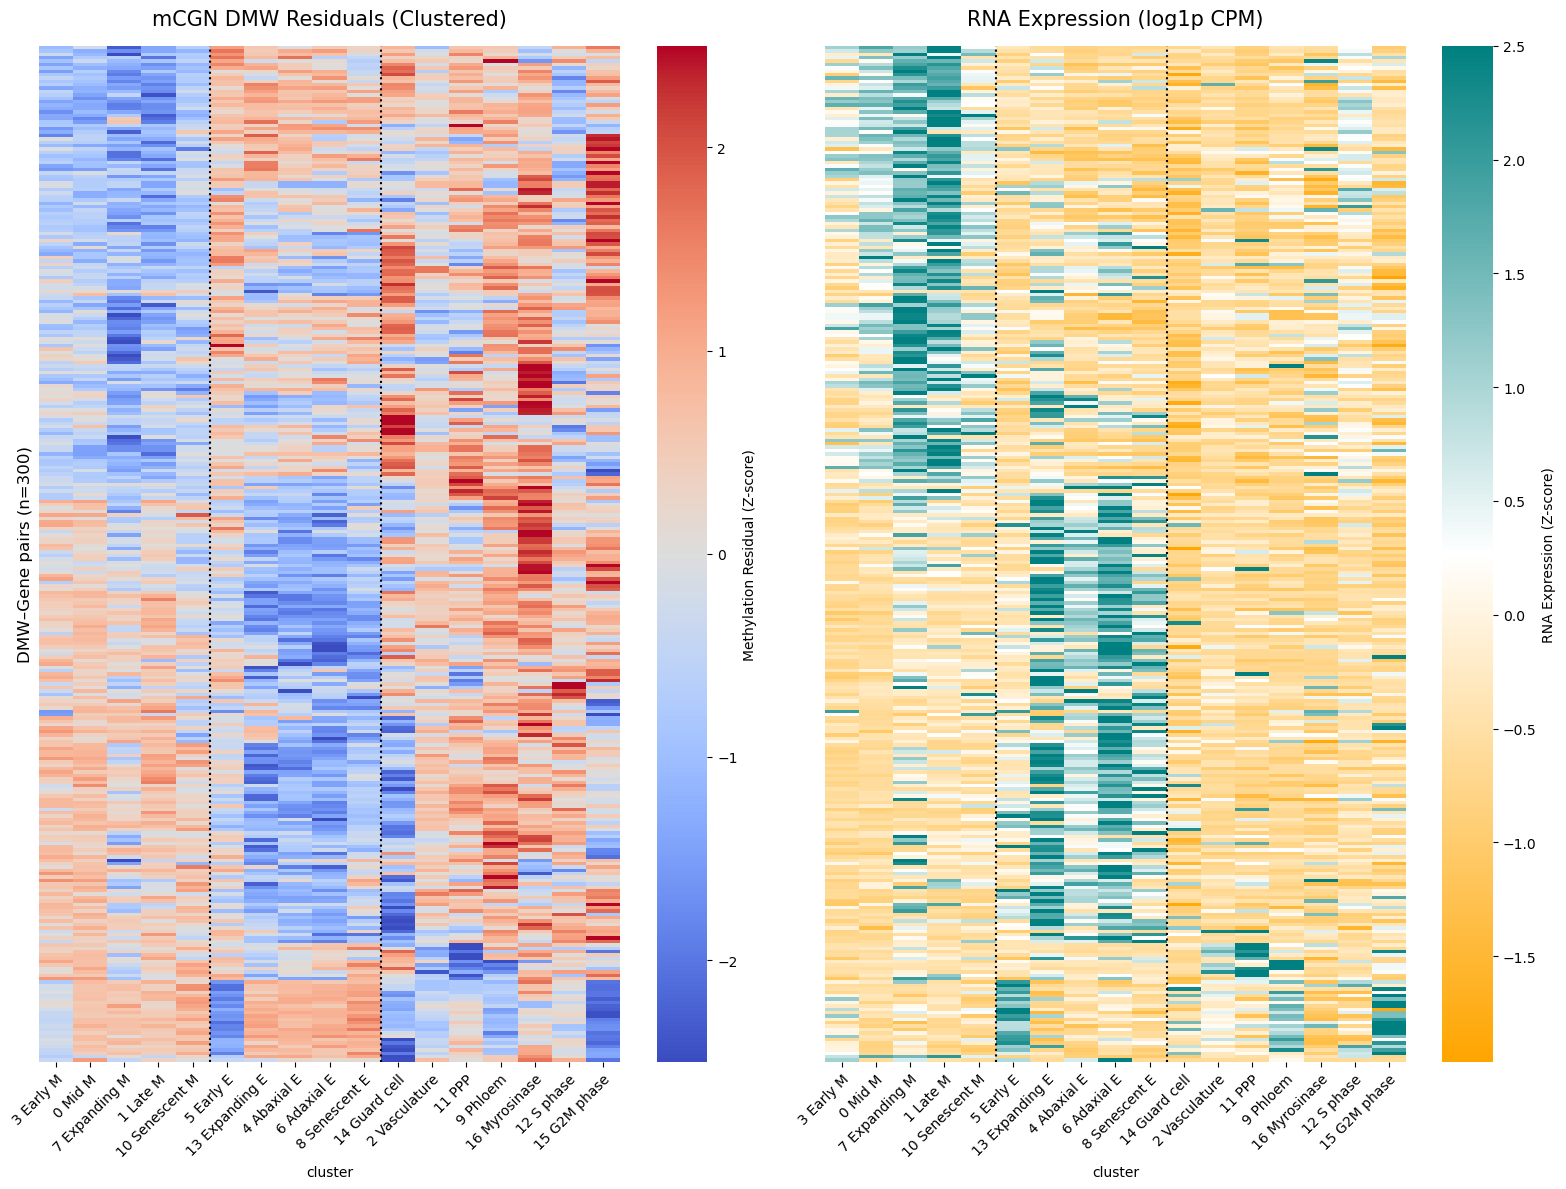

In [13]:
# ---------- Cell 8: heatmap of top anti-correlated DMW-gene pairs ----------

import os
os.makedirs(fig_outdir, exist_ok=True)
plt.savefig(f"{fig_outdir}/minfilt_dmw_rna_wls_top300_clustered_heatmap.png",
               dpi=300, bbox_inches="tight")

cluster_mapping = {
    3: '3 Early M', 0: '0 Mid M', 7: '7 Expanding M', 1: '1 Late M', 10: '10 Senescent M',
    5: '5 Early E', 4: '4 Abaxial E', 6: '6 Adaxial E', 13: '13 Expanding E', 8: '8 Senescent E',
    14: '14 Guard cell', 2: '2 Vasculature', 11: '11 PPP', 9: '9 Phloem',
    16: '16 Myrosinase', 12: '12 S phase', 15: '15 G2M phase'
}
cluster_mapping.update({str(k): v for k, v in cluster_mapping.items()})

cluster_order = [
    '3 Early M', '0 Mid M', '7 Expanding M', '1 Late M', '10 Senescent M',
    '5 Early E', '13 Expanding E', '4 Abaxial E', '6 Adaxial E', '8 Senescent E',
    '14 Guard cell', '2 Vasculature', '11 PPP', '9 Phloem',
    '16 Myrosinase', '12 S phase', '15 G2M phase'
]

# Top 300 most negatively correlated DMW–gene pairs (FDR-significant if you want)
top_pairs = stats_df.sort_values("rho").head(300).reset_index(drop=True)
print(f"Plotting top {len(top_pairs)} DMW-gene pairs.")

# Build matched matrices: one row per pair
meth_rows = filtered_meth_df.loc[top_pairs["dmw_id"].values].copy()
rna_rows  = cluster_rna_matrix.loc[top_pairs["gene"].values].copy()

# Use a unique label per row so duplicated genes/DMWs don't collide
row_labels = [f"{d} | {g}" for d, g in zip(top_pairs["dmw_id"], top_pairs["gene"])]
meth_rows.index = row_labels
rna_rows.index  = row_labels

def prepare_zscore(df):
    z = df.apply(zscore, axis=1)
    return z.clip(lower=-2.5, upper=2.5)

vis_meth_z = prepare_zscore(meth_rows)
vis_rna_z  = prepare_zscore(rna_rows)

# Rename + reorder columns (clusters)
vis_meth_z = vis_meth_z.rename(columns=cluster_mapping)
vis_rna_z  = vis_rna_z.rename(columns=cluster_mapping)

clusters_to_drop = []
valid_order = [c for c in cluster_order
               if c in vis_meth_z.columns and c not in clusters_to_drop]
vis_meth_z = vis_meth_z[valid_order]
vis_rna_z  = vis_rna_z[valid_order]

# Cluster rows by methylation pattern, apply same order to RNA
row_linkage = hc.linkage(sp.distance.pdist(vis_meth_z.values), method="ward")
row_order   = hc.leaves_list(row_linkage)
vis_meth_clustered = vis_meth_z.iloc[row_order]
vis_rna_clustered  = vis_rna_z.iloc[row_order]

rna_cmap = LinearSegmentedColormap.from_list("Orange_White_Teal",
                                             ["orange", "white", "teal"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 12),
                               gridspec_kw={"width_ratios": [1, 1]})

sns.heatmap(vis_meth_clustered, cmap="coolwarm", center=0, ax=ax1,
            cbar_kws={"label": "Methylation Residual (Z-score)"},
            yticklabels=False)
ax1.set_title(f"m{MC_TYPE} DMW Residuals (Clustered)", fontsize=15, pad=15)
ax1.set_ylabel(f"DMW–Gene pairs (n={len(top_pairs)})", fontsize=12)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right",
                    rotation_mode="anchor")

sns.heatmap(vis_rna_clustered, cmap=rna_cmap, ax=ax2,
            cbar_kws={"label": "RNA Expression (Z-score)"},
            yticklabels=False)
ax2.set_title("RNA Expression (log1p CPM)", fontsize=15, pad=15)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right",
                    rotation_mode="anchor")

# Optional: keep your senescent-stage dividers
divider_positions = []
for i, col_name in enumerate(valid_order):
    if "Senescent M" in col_name or "Senescent E" in col_name:
        divider_positions.append(i + 1)
for ax in [ax1, ax2]:
    for pos in divider_positions:
        ax.axvline(pos, color="black", lw=1.5, linestyle=":")

plt.tight_layout()
plt.savefig("./figures/heatmaps/minfilt_dmw_rna_wls_top300_clustered_heatmap.png",
            format="png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
sig_neg_005 = stats_df[(stats_df["fdr"] < 0.05) & (stats_df["rho"] < 0)]
sig_neg_010 = stats_df[(stats_df["fdr"] < 0.10) & (stats_df["rho"] < 0)]
sig_pos_005 = stats_df[(stats_df["fdr"] < 0.05) & (stats_df["rho"] > 0)]

print(f"Total tested DMW-gene pairs: {len(stats_df)}")
print(f"FDR<0.05 negative: {len(sig_neg_005)}  (was 7 with full chunk set)")
print(f"FDR<0.10 negative: {len(sig_neg_010)}")
print(f"FDR<0.05 positive: {len(sig_pos_005)}")

# Save the updated stats table
stats_df.sort_values("rho").to_csv(
    f"{fig_outdir}/../dmw_gene_wls_stats_curated.tsv",
    sep="\t", index=False)

Total tested DMW-gene pairs: 1204
FDR<0.05 negative: 234  (was 7 with full chunk set)
FDR<0.10 negative: 294
FDR<0.05 positive: 25


In [15]:
!pwd

/ceph/MethDev/pbio/andy/JW/section_4/kay


Clustering 3054 DMWs across 17 clusters
Saved: /ceph/MethDev/pbio/andy/JW/section_4/kay/figures/heatmaps/all_curated_dmws_methylation_clustermap.png


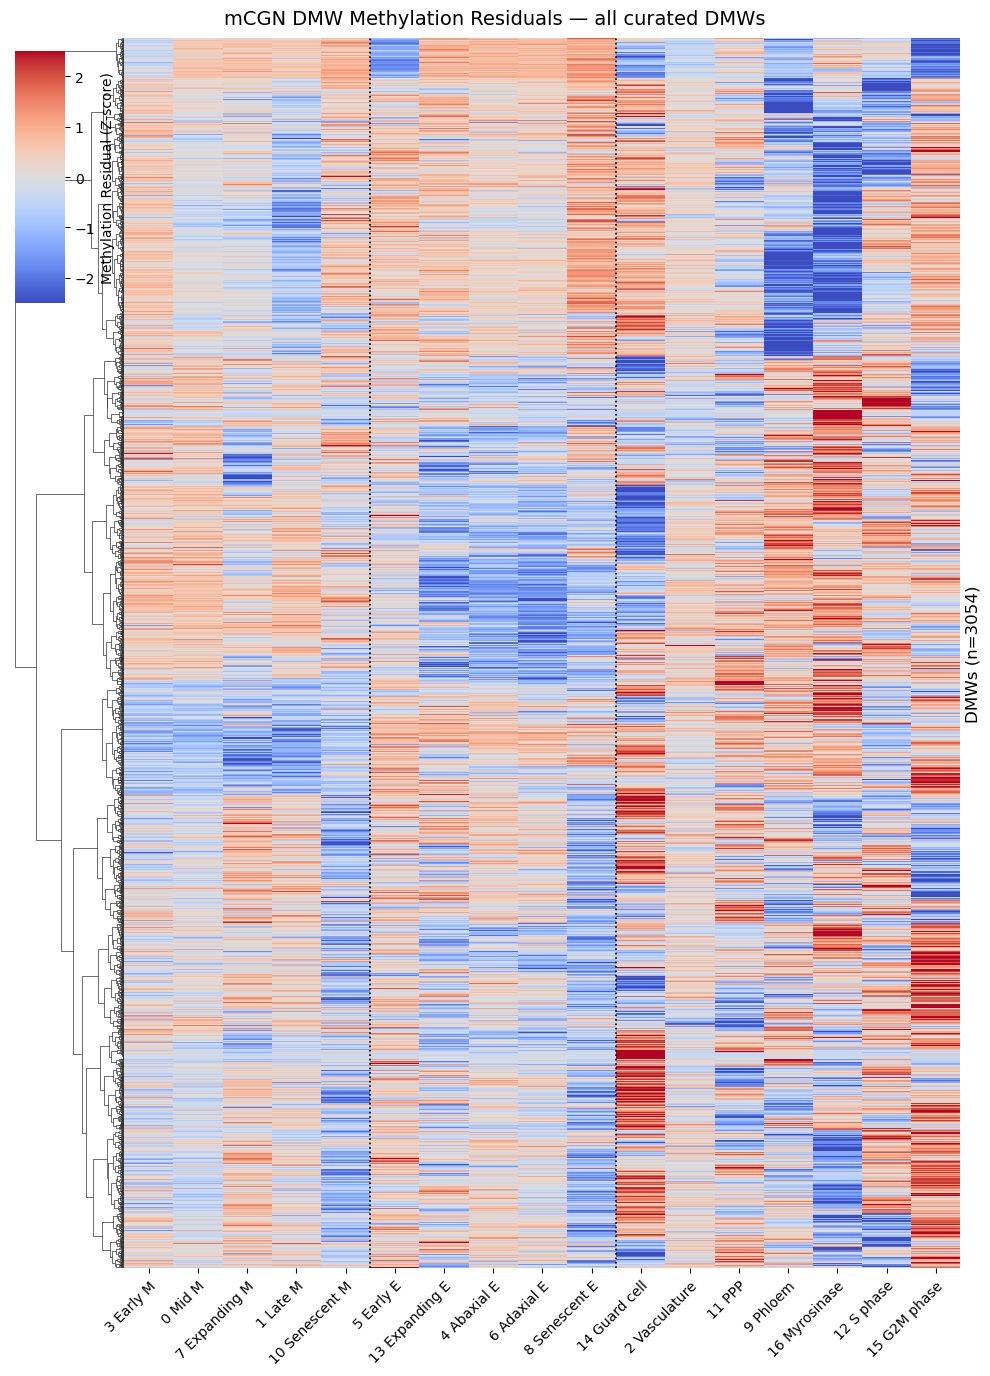

In [17]:
# ---------- Clustermap of all curated DMWs by methylation residual ----------
import os
os.makedirs(fig_outdir, exist_ok=True)

# Z-score each row, clip extremes for color stability
def prepare_zscore(df):
    z = df.apply(zscore, axis=1)
    return z.clip(lower=-2.5, upper=2.5)

vis_meth_z = prepare_zscore(filtered_meth_df).rename(columns=cluster_mapping)

# Reorder columns to your biological cluster order; drop any missing
clusters_to_drop = []
valid_order = [c for c in cluster_order
               if c in vis_meth_z.columns and c not in clusters_to_drop]
vis_meth_z = vis_meth_z[valid_order]

print(f"Clustering {len(vis_meth_z)} DMWs across {len(valid_order)} clusters")

# seaborn clustermap: rows clustered, columns kept in given order
g = sns.clustermap(
    vis_meth_z,
    cmap="coolwarm", center=0,
    row_cluster=True, col_cluster=False,   # keep biological column order
    method="ward", metric="euclidean",
    yticklabels=False,
    figsize=(10, 14),
    cbar_kws={"label": "Methylation Residual (Z-score)"},
    dendrogram_ratio=(0.12, 0.0),          # row dendro on left, no col dendro
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(),
                             rotation=45, ha="right", rotation_mode="anchor")
g.ax_heatmap.set_ylabel(f"DMWs (n={len(vis_meth_z)})", fontsize=12)
g.ax_heatmap.set_xlabel("")
g.fig.suptitle(f"m{MC_TYPE} DMW Methylation Residuals — all curated DMWs",
               fontsize=14, y=1.01)

# Optional senescent dividers
for i, col_name in enumerate(valid_order):
    if "Senescent M" in col_name or "Senescent E" in col_name:
        g.ax_heatmap.axvline(i + 1, color="black", lw=1.2, linestyle=":")

out_path = f"{fig_outdir}/all_curated_dmws_methylation_clustermap.png"
g.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

Clustering 3054 DMWs across 17 clusters
Saved: /ceph/MethDev/pbio/andy/JW/section_4/kay/figures/heatmaps/all_curated_dmws_methylation_clustermap_bothclust.png


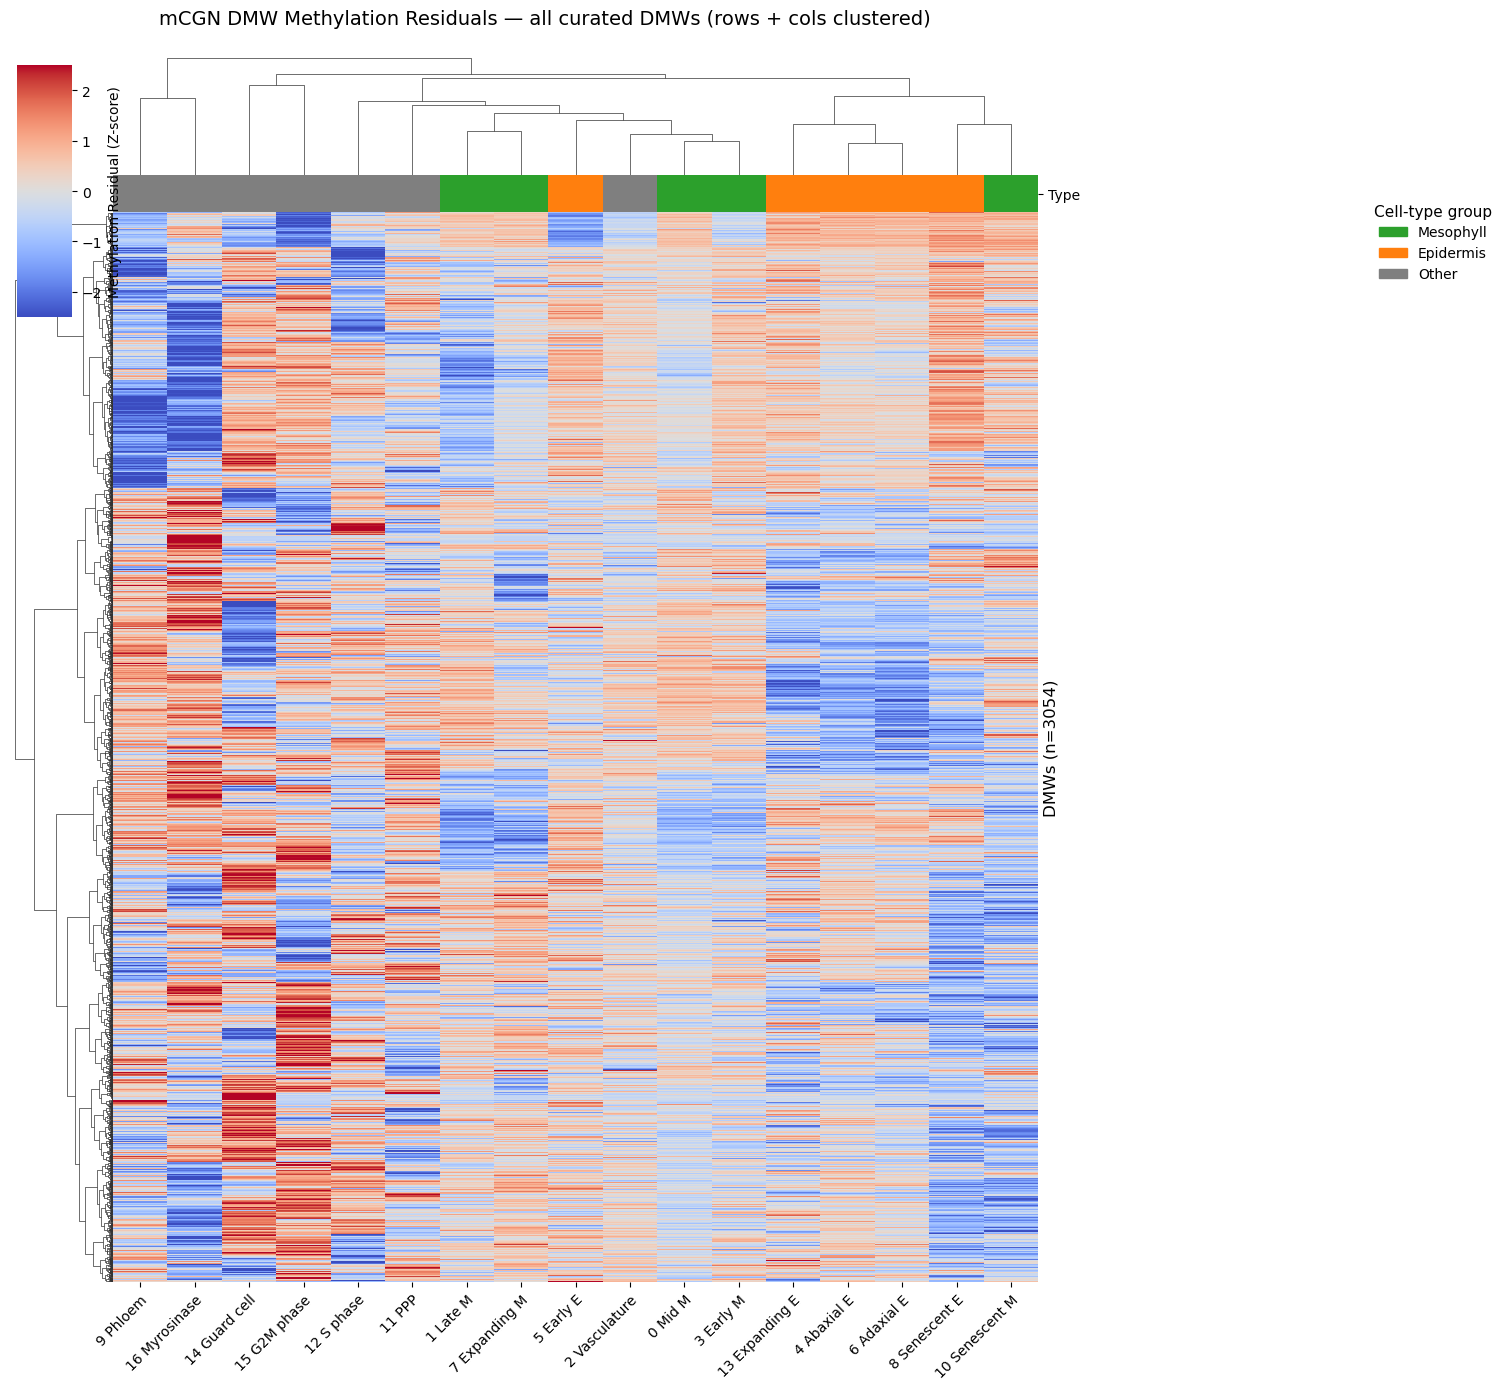

In [18]:
# ---------- Clustermap with both rows and columns clustered, color-coded column types ----------
import os
os.makedirs(fig_outdir, exist_ok=True)

# === 1. Define the three biological groups ===
type_groups = {
    'Mesophyll':  ['3 Early M', '0 Mid M', '7 Expanding M', '1 Late M', '10 Senescent M'],
    'Epidermis':  ['5 Early E', '13 Expanding E', '4 Abaxial E', '6 Adaxial E', '8 Senescent E'],
    'Other':      ['14 Guard cell', '2 Vasculature', '11 PPP', '9 Phloem',
                   '16 Myrosinase', '12 S phase', '15 G2M phase'],
}

type_colors = {
    'Mesophyll': '#2ca02c',   # green
    'Epidermis': '#ff7f0e',   # orange
    'Other':     '#7f7f7f',   # grey
}

# Build a flat dict: cluster_label → type
cluster_to_type = {col: t for t, cols in type_groups.items() for col in cols}

# === 2. Prepare the matrix ===
def prepare_zscore(df):
    z = df.apply(zscore, axis=1)
    return z.clip(lower=-2.5, upper=2.5)

vis_meth_z = prepare_zscore(filtered_meth_df).rename(columns=cluster_mapping)

# Drop any unmapped/extra columns just in case
vis_meth_z = vis_meth_z[[c for c in vis_meth_z.columns if c in cluster_to_type]]
print(f"Clustering {len(vis_meth_z)} DMWs across {vis_meth_z.shape[1]} clusters")

# === 3. Build column color strip (one color per cluster column) ===
col_colors = pd.Series(
    {col: type_colors[cluster_to_type[col]] for col in vis_meth_z.columns},
    name='Type',
)

# === 4. Clustermap with both rows and columns clustered ===
g = sns.clustermap(
    vis_meth_z,
    cmap="coolwarm", center=0, vmin=-2.5, vmax=2.5,
    row_cluster=True,
    col_cluster=True,                      # <-- columns now clustered too
    method="ward", metric="euclidean",
    col_colors=col_colors,                 # color strip above heatmap
    yticklabels=False,
    figsize=(11, 14),
    cbar_kws={"label": "Methylation Residual (Z-score)"},
    dendrogram_ratio=(0.10, 0.10),
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(),
                             rotation=45, ha="right", rotation_mode="anchor")
g.ax_heatmap.set_ylabel(f"DMWs (n={len(vis_meth_z)})", fontsize=12)
g.ax_heatmap.set_xlabel("")

g.fig.suptitle(
    f"m{MC_TYPE} DMW Methylation Residuals — all curated DMWs (rows + cols clustered)",
    fontsize=14, y=1.02)

# === 5. Legend for the type color strip ===
import matplotlib.patches as mpatches
legend_handles = [mpatches.Patch(color=c, label=t) for t, c in type_colors.items()]
g.ax_heatmap.legend(
    handles=legend_handles,
    title="Cell-type group",
    bbox_to_anchor=(1.35, 1.02),
    loc='upper left',
    frameon=False,
    fontsize=10, title_fontsize=11,
)

out_path = f"{fig_outdir}/all_curated_dmws_methylation_clustermap_bothclust.png"
g.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

In [ ]:
# ================================================================
# EXTRACT DATA MATRICES BEHIND THE CLUSTERMAP
# ----------------------------------------------------------------
# Save the two matrices that feed the all-DMW clustermap:
#   1. RAW per-cluster methylation fraction (obs_p = mc / cov)
#   2. PER-CLUSTER-NORMALIZED residual          (obs_p - p0)
# Both are DMW x merged_cluster.  No z-scoring is applied here;
# the clustermap z-scored only for color stability.
# ================================================================
import os

matrix_outdir = "/ceph/MethDev/pbio/andy/JW/section_4/kay/data/dmw_matrices_by_genotype"
os.makedirs(matrix_outdir, exist_ok=True)

# --- Observed fraction (raw scores) for the SAME DMWs that went into ---
# --- filtered_meth_df (i.e., the rows of the clustermap)             ---
raw_methylation_col = obs_p.loc[filtered_meth_df.index].copy()
residual_col        = filtered_meth_df.copy()   # already obs_p - p0

# Rename columns from numeric cluster IDs to merged cluster labels,
# then reorder to the canonical biological order.
raw_methylation_col = raw_methylation_col.rename(columns=cluster_mapping)
residual_col        = residual_col.rename(columns=cluster_mapping)
ordered_cols        = [c for c in cluster_order if c in raw_methylation_col.columns]
raw_methylation_col = raw_methylation_col[ordered_cols]
residual_col        = residual_col[ordered_cols]

# Save (genotype tag "col_mcds" = derived from the cell-level MCDS pipeline)
raw_methylation_col.to_csv(
    f"{matrix_outdir}/col_mcds_dmw_raw_methylation.tsv", sep="\t")
residual_col.to_csv(
    f"{matrix_outdir}/col_mcds_dmw_residual_methylation.tsv", sep="\t")

print(f"Saved col-0 (MCDS-derived) matrices to {matrix_outdir}")
print(f"  raw:      {raw_methylation_col.shape}  range [{raw_methylation_col.values.min():.3f}, "
      f"{raw_methylation_col.values.max():.3f}]")
print(f"  residual: {residual_col.shape}  range [{residual_col.values.min():.3f}, "
      f"{residual_col.values.max():.3f}]")
raw_methylation_col.head()


In [ ]:
# ================================================================
# BUILD raw 21-cluster -> merged 17-cluster MAPPING
# ----------------------------------------------------------------
# The bulk per-(cluster, genotype) ALLC files at
#   /ceph/MethDev/pbio/andy/JW/section_4/merged_allc_by_clst_genotype/
# are keyed by 21 raw clusters.  The notebook (and the col-0 MCDS
# pipeline above) operates on 17 merged clusters.  Build the
# raw -> dominant-merged mapping by joining the two annotation CSVs.
# Print a QC table flagging raw clusters whose dominant fraction is
# below 0.7 (i.e., ambiguous mappings).
# ================================================================
raw_assign = pd.read_csv(
    "/ceph/MethDev/pbio/andy/JW/section_4/cell_cluster_assignment.csv")
mrg_assign = pd.read_csv(
    "/ceph/MethDev/pbio/hazel/merged_cluster_assignments.csv",
    dtype={"merged_cluster": str})

join = raw_assign.merge(mrg_assign, on="cell_id")
join["cluster_id"] = join["cluster_id"].astype(int)

xtab = pd.crosstab(join["cluster_id"], join["merged_cluster"])
xtab = xtab.reindex(index=range(21),
                    columns=[str(i) for i in range(17)],
                    fill_value=0)

raw_to_merged = pd.DataFrame({
    "dominant_merged":   xtab.idxmax(axis=1),
    "dominant_fraction": (xtab.max(axis=1) / xtab.sum(axis=1).replace(0, 1)).round(3),
    "n_cells":           xtab.sum(axis=1).astype(int),
})

print("raw -> merged cluster mapping (dominant assignment):")
print(raw_to_merged)
print()
ambiguous = raw_to_merged[raw_to_merged["dominant_fraction"] < 0.7]
print(f"Ambiguous mappings (dominant_fraction < 0.7): {len(ambiguous)}")
if len(ambiguous):
    print(ambiguous)
print("\nNote: raw cluster bulk-ALLC counts will be assigned to the dominant merged "
      "cluster.  For ambiguous clusters, this approximation will mix in cells that "
      "actually belong to other merged groups; treat residuals from those merged "
      "clusters with caution if the contributing raw clusters were ambiguous.")

raw_to_merged.to_csv(f"{matrix_outdir}/raw21_to_merged17_mapping.tsv", sep="\t")


In [ ]:
# ================================================================
# CG mc/cov EXTRACTOR FOR ONE (raw_cluster, genotype) BULK ALLC
# ----------------------------------------------------------------
# Uses tabix region queries to pull CG-context positions inside each
# DMW interval, then sums mc and cov.  ALLC chrom names are bare
# integers (1..5), and ALLC positions are 1-based; tabix.fetch takes
# (chrom, start_0based, end_exclusive).
# ================================================================
import pysam

ALLC_DIR = "/ceph/MethDev/pbio/andy/JW/section_4/merged_allc_by_clst_genotype"

# DMW intervals to extract over: the SAME DMWs used for the clustermap.
# Pull coords back from MCDS for the curated chunks, then restrict to
# filtered_meth_df rows so raw + residual matrices have identical rows.
dmw_intervals = pd.DataFrame({
    "chrom":  mcds["dmw_chrom"].values.astype(str),
    "start":  mcds["dmw_start"].values.astype(int),     # 1-based inclusive
    "end":    mcds["dmw_end"].values.astype(int),       # 1-based inclusive
    "dmw_id": mcds.get_index("dmw").values,
}).set_index("dmw_id").loc[filtered_meth_df.index].reset_index()
print(f"Target DMWs: {len(dmw_intervals)}")


def extract_dmw_mc_cov(raw_cluster: int, genotype: str,
                       intervals: pd.DataFrame = dmw_intervals) -> pd.DataFrame:
    """Return DataFrame indexed by dmw_id with columns [mc, cov] for CG context."""
    path = f"{ALLC_DIR}/clst{raw_cluster}.{genotype}.allc.tsv.gz"
    tbx  = pysam.TabixFile(path)

    mc_out  = np.zeros(len(intervals), dtype=np.int64)
    cov_out = np.zeros(len(intervals), dtype=np.int64)

    for i, row in enumerate(intervals.itertuples(index=False)):
        try:
            it = tbx.fetch(row.chrom, row.start - 1, row.end)   # 0-based half-open
        except (ValueError, OSError):
            continue
        mc_sum = 0
        cov_sum = 0
        for line in it:
            # chr  pos  strand  context  mc  cov  methylated
            fields = line.split("\t")
            ctx = fields[3]
            if ctx[0] == "C" and ctx[1] == "G":   # CG context (CGA/CGC/CGG/CGT/CGN)
                mc_sum  += int(fields[4])
                cov_sum += int(fields[5])
        mc_out[i]  = mc_sum
        cov_out[i] = cov_sum

    tbx.close()
    return pd.DataFrame({"mc": mc_out, "cov": cov_out},
                        index=intervals["dmw_id"].values)


# Smoke test: one cluster
test_df = extract_dmw_mc_cov(0, "col")
print(f"Smoke test clst0.col: {test_df.shape}, cov range "
      f"[{test_df['cov'].min()}, {test_df['cov'].max()}], "
      f"mean obs_p = {(test_df['mc'].sum() / max(test_df['cov'].sum(), 1)):.4f}")
test_df.head()


In [ ]:
# ================================================================
# FULL WORKFLOW FOR ONE GENOTYPE
# ----------------------------------------------------------------
# 1. Pull (mc, cov) per DMW for each of the 21 raw clusters.
# 2. Pool raw clusters into 17 merged clusters using raw_to_merged.
# 3. Compute obs_p = mc / cov (raw fraction) and the per-cluster
#    residual obs_p - p0 using the same logit-offset math as the
#    col-0 MCDS pipeline.
# 4. Save four TSVs:
#      <g>_dmw_mc_counts.tsv          merged_cluster sums of mc
#      <g>_dmw_cov_counts.tsv         merged_cluster sums of cov
#      <g>_dmw_raw_methylation.tsv    obs_p
#      <g>_dmw_residual_methylation.tsv  obs_p - p0
# ================================================================
from joblib import Parallel, delayed


def build_genotype_matrices(genotype: str, n_jobs: int = 8,
                            min_cov_per_dmw: int = 50) -> dict:
    print(f"\n=== {genotype} ===")

    # 1. (mc, cov) per (DMW, raw cluster), parallel across raw clusters.
    # Skip raw clusters with no ALLC for this genotype (e.g. clst20.met is
    # absent because raw cluster 20 had only 10 cells, none of them met).
    available_raw, missing_raw = [], []
    for c in range(21):
        if os.path.exists(f"{ALLC_DIR}/clst{c}.{genotype}.allc.tsv.gz"):
            available_raw.append(c)
        else:
            missing_raw.append(c)
    if missing_raw:
        print(f"  [info] no ALLC for clst{missing_raw} in {genotype}; contributing zeros")

    raw_results = Parallel(n_jobs=n_jobs)(
        delayed(extract_dmw_mc_cov)(c, genotype) for c in available_raw
    )
    mc_raw  = pd.concat({c: r["mc"]  for c, r in zip(available_raw, raw_results)}, axis=1)
    cov_raw = pd.concat({c: r["cov"] for c, r in zip(available_raw, raw_results)}, axis=1)
    mc_raw.columns.name  = "raw_cluster"
    cov_raw.columns.name = "raw_cluster"

    # 2. Pool raw -> merged by summing mc and cov within each merged group
    raw_to_merged_int = raw_to_merged["dominant_merged"].astype(int).loc[mc_raw.columns]
    mc_merged  = mc_raw.groupby(raw_to_merged_int,  axis=1).sum()
    cov_merged = cov_raw.groupby(raw_to_merged_int, axis=1).sum()
    # Ensure all 17 merged clusters are present
    for k in range(17):
        if k not in mc_merged.columns:
            mc_merged[k]  = 0
            cov_merged[k] = 0
    mc_merged  = mc_merged[sorted(mc_merged.columns)]
    cov_merged = cov_merged[sorted(cov_merged.columns)]

    # 3a. obs_p = mc / cov   (NaN where cov == 0)
    obs_p_g = (mc_merged / cov_merged.where(cov_merged > 0)).astype(float)

    # 3b. per-cluster logit offsets fit on the genotype's own coverage
    global_c = mc_merged.sum(axis=0)
    global_m = cov_merged.sum(axis=0)
    global_p = global_c / global_m.replace(0, np.nan)
    d_g      = logit(np.clip(global_p, 1e-6, 1 - 1e-6))
    deltas_g = d_g - np.average(d_g, weights=global_m)

    # 3c. expected (cluster-adjusted) prob per DMW, then residual
    dmw_c = mc_merged.sum(axis=1)
    dmw_m = cov_merged.sum(axis=1)
    valid_dmw = dmw_m >= min_cov_per_dmw
    pbar = np.clip(dmw_c / dmw_m.replace(0, np.nan), 1e-6, 1 - 1e-6)
    expected_logit = logit(pbar).values[:, None] + deltas_g.values[None, :]
    p0_g = pd.DataFrame(expit(expected_logit),
                        index=mc_merged.index, columns=mc_merged.columns)
    residual_g = obs_p_g - p0_g

    # 3d. Mask DMWs that fail the coverage filter (for QC clarity)
    obs_p_g.loc[~valid_dmw]    = np.nan
    residual_g.loc[~valid_dmw] = np.nan

    # 4. Rename columns to merged cluster labels, reorder, save
    cm = {int(k): v for k, v in cluster_mapping.items()
          if isinstance(k, int) or (isinstance(k, str) and k.isdigit())}
    def relabel(df):
        df = df.rename(columns=cm)
        return df[[c for c in cluster_order if c in df.columns]]

    mc_out  = relabel(mc_merged)
    cov_out = relabel(cov_merged)
    raw_out = relabel(obs_p_g)
    res_out = relabel(residual_g)

    mc_out .to_csv(f"{matrix_outdir}/{genotype}_dmw_mc_counts.tsv",         sep="\t")
    cov_out.to_csv(f"{matrix_outdir}/{genotype}_dmw_cov_counts.tsv",        sep="\t")
    raw_out.to_csv(f"{matrix_outdir}/{genotype}_dmw_raw_methylation.tsv",   sep="\t")
    res_out.to_csv(f"{matrix_outdir}/{genotype}_dmw_residual_methylation.tsv", sep="\t")

    print(f"  DMWs passing coverage filter (sum cov >= {min_cov_per_dmw}): "
          f"{int(valid_dmw.sum())}/{len(valid_dmw)}")
    print(f"  Saved 4 TSVs to {matrix_outdir}/{genotype}_dmw_*.tsv")

    return {
        "mc": mc_out, "cov": cov_out,
        "raw_methylation": raw_out, "residual": res_out,
        "deltas": deltas_g,
    }


In [ ]:
# ================================================================
# RUN: extract matrices for all three genotypes
# ----------------------------------------------------------------
# This reads ~21 * 3 = 63 bulk ALLC files via tabix.  With n_jobs=8
# it takes a few minutes per genotype.  Lower n_jobs if memory tight.
# ================================================================
genotype_matrices = {}
for g in ["col", "met", "rdd"]:
    genotype_matrices[g] = build_genotype_matrices(g, n_jobs=8)

print("\nAll done. Files in:", matrix_outdir)
print(sorted(os.listdir(matrix_outdir)))


In [ ]:
# ================================================================
# SANITY CHECK: col_bulk_ALLC residuals  vs  col_mcds residuals
# ----------------------------------------------------------------
# The two col-0 pipelines compute residuals from independent
# aggregations (cell-MCDS sum vs bulk-ALLC sum) but should agree
# closely on DMWs that pass both coverage filters.  Per-DMW
# Pearson correlation across the 17 clusters is reported.
# ================================================================
col_bulk = genotype_matrices["col"]["residual"]
col_mcds = residual_col

shared_dmw = col_bulk.index.intersection(col_mcds.index)
shared_col = col_bulk.columns.intersection(col_mcds.columns)
A = col_bulk.loc[shared_dmw, shared_col]
B = col_mcds.loc[shared_dmw, shared_col]
both_ok = A.notna().all(axis=1) & B.notna().all(axis=1)
A, B = A[both_ok], B[both_ok]
print(f"Sanity check on {len(A)} DMWs x {A.shape[1]} clusters")

# Per-DMW correlation across clusters
per_dmw_corr = pd.Series(
    [np.corrcoef(a, b)[0, 1] for a, b in zip(A.values, B.values)],
    index=A.index,
)
print(f"Per-DMW correlation (col_bulk vs col_mcds residuals):")
print(per_dmw_corr.describe())

# Flat correlation across the whole matrix
flat = np.corrcoef(A.values.ravel(), B.values.ravel())[0, 1]
print(f"\nFlat overall Pearson correlation: {flat:.4f}")

# Quick scatter
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(B.values.ravel(), A.values.ravel(), s=2, alpha=0.2, rasterized=True)
lim = (-0.6, 0.6)
ax.plot(lim, lim, "k--", lw=1)
ax.set(xlabel="col_mcds residual", ylabel="col_bulk-ALLC residual",
       xlim=lim, ylim=lim,
       title=f"col-0: bulk-ALLC vs MCDS residuals  (r = {flat:.3f})")
plt.tight_layout()
plt.savefig(f"{fig_outdir}/col_bulk_vs_mcds_residual_scatter.png",
            dpi=200, bbox_inches="tight")
plt.show()
